In [38]:
import pandas as pd 
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt 
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import statsmodels.api as sm
import pmdarima as pm


In [39]:
# metrics that will be used later

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def mae(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred))) 


def ljung_box_test(residuals, is_seasonal, period):
    
    if is_seasonal:
        lb_df = acorr_ljungbox(residuals, period=period)
    else:
        max_lag = min([10, len(residuals)/5])
        
        lb_df = acorr_ljungbox(residuals, np.arange(1, max_lag+1, 1))

    fig, ax = plt.subplots()
    ax.plot(lb_df['lb_pvalue'], 'b-', label='p-values')
    ax.hlines(y=0.05, xmin=1, xmax=len(lb_df), color='black')
    plt.tight_layout()
    
    if all(pvalue > 0.05 for pvalue in lb_df['lb_pvalue']):
        print('All values are above 0.05. We fail to reject the null hypothesis. The residuals are uncorrelated')
    else:
        print('At least one p-value is smaller than 0.05')

In [9]:
df = pd.read_csv('/home/uplong/Documents/DSU-analytics-comp-2026/data/grouped_by_year_month.csv', parse_dates=['Date'])
df = df.set_index('Date')
df = df.drop(columns=['unique_entry_per_day', 'total_admittances'])

In [4]:
df

,total_encounters
Date,
2018-01-01,13657
2018-02-01,12232
2018-03-01,13101
2018-04-01,12842
2018-05-01,13797
...,...
2025-04-01,14549
2025-05-01,15047
2025-06-01,14864


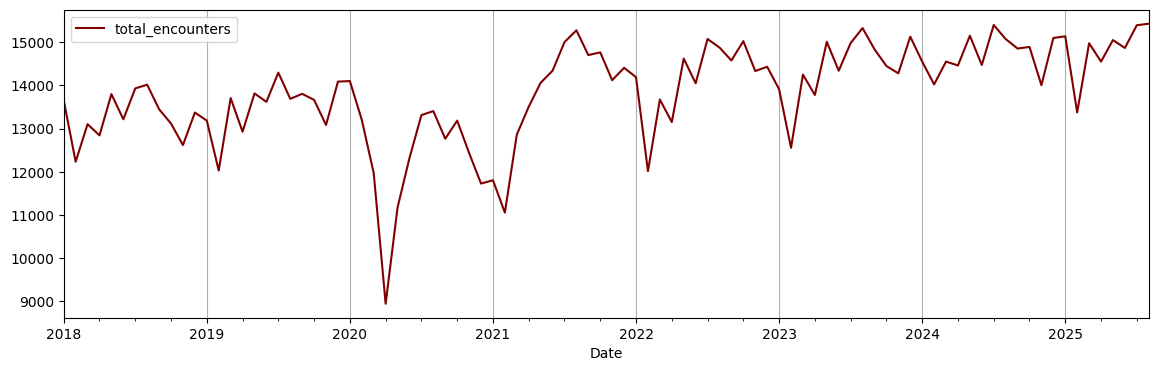

In [7]:
df.plot(
    kind='line',
    figsize=(14,4),
    color='maroon'
)
plt.grid(axis='x')
plt.show()

In [10]:
# Check stationarity
ad_index = adfuller(df)[0]
p_val = adfuller(df)[1]

print(f'Adfuller Index: {ad_index}')
print(f'p-val: {p_val}')
print(f'Stationarity: {p_val<=5e-2}')


Adfuller Index: -1.0960748954677326
p-val: 0.7166346504523546
Stationarity: False


In [11]:
# Make stationary
diff = np.diff(df.total_encounters, n=1)

ad_index = adfuller(diff)[0]
p_val = adfuller(diff)[1]

print(f'Adfuller Index: {ad_index}')
print(f'p-val: {p_val}')
print(f'Stationarity: {p_val<=5e-2}')

Adfuller Index: -3.7557949423495027
p-val: 0.003393390693766845
Stationarity: True


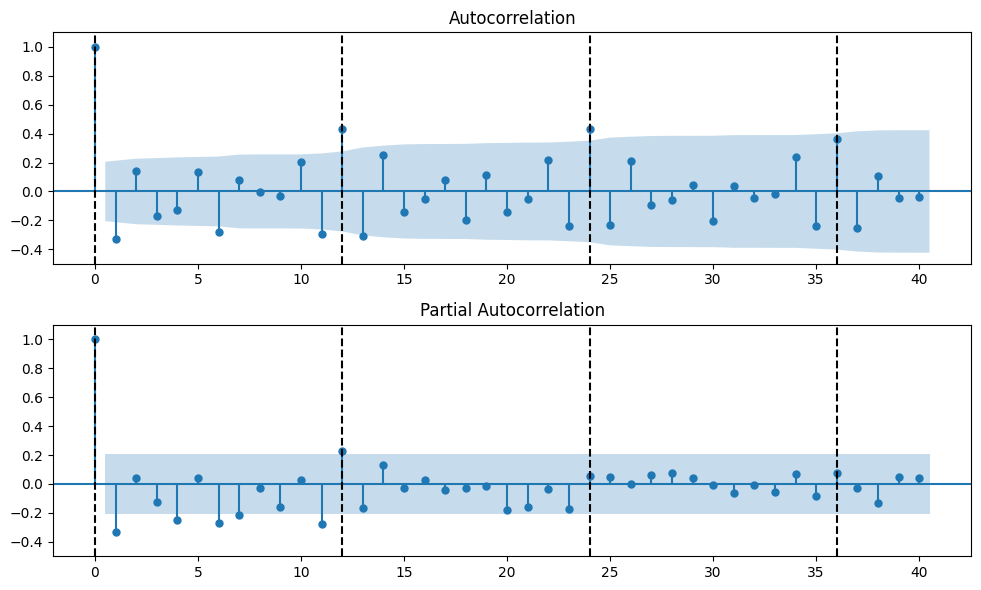

In [12]:
# Check ACF and PACF
LAGS = 40

fig, ax = plt.subplots(2,1, figsize=(10,6))

plot_acf(diff, lags=LAGS, ax=ax[0])
ax[0].vlines(list(range(0,LAGS,12)), ymin=-.5, ymax=1.1, color='black', linestyle='--')
ax[0].set_ylim(-.5,1.1)

plot_pacf(diff, lags=LAGS, ax=ax[1])
ax[1].vlines(list(range(0,LAGS,12)), ymin=-.5, ymax=1.1, color='black', linestyle='--')
ax[1].set_ylim(-.5,1.1)

plt.tight_layout()
plt.show()

We find possible seasonality pattern every 12 months. Let's try and verify it visually.

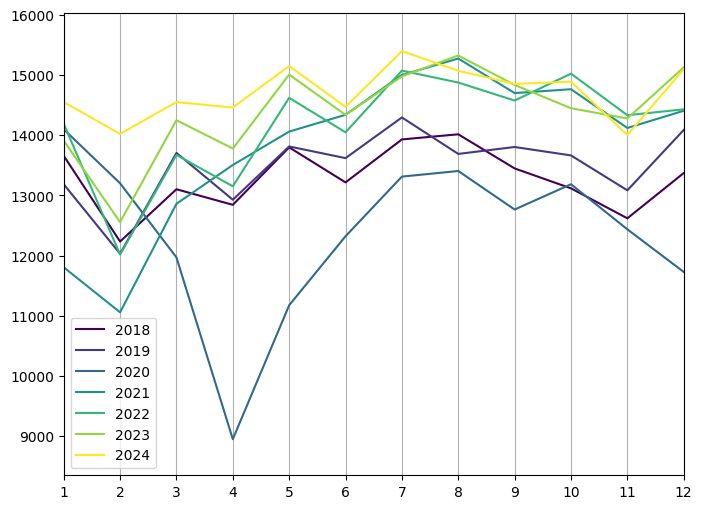

In [13]:
y_min_lim = np.int16(df.min()) - 500
y_max_lim = np.int16(df.max()) + 500

plt.figure(figsize=(8, 6))

cmap = plt.cm.viridis
years = range(2018, 2025)

for i, year in enumerate(years):
    plt.plot(
        df[df.index.year == year].to_numpy(),
        label=str(year),
        color=cmap(i / (len(years) - 1))
    )

plt.xlim(0,11)
plt.xticks(list(range(0,12,1)), labels=list(range(1,13,1)))
plt.ylim(y_min_lim-100, y_max_lim+100)
plt.legend()
plt.grid(axis='x')
plt.show()

Indeed, apart from 2020 there seems to be a pattern. We will see how we can handle the outlier year 2020.

So far we've taken care of a trend by taking the differences, and we have found a seasonality every 12 months, that's why we possibly need to take differences once more every 12 entries.



In [14]:
diff_12 = np.diff(diff, n=12)

# Check stationarity (redundant since we already have stationarity from diff = 1)

ad_index = adfuller(diff_12)[0]
p_val = adfuller(diff_12)[1]

print(f'Adfuller Index: {ad_index}')
print(f'p-val: {p_val}')
print(f'Stationarity: {p_val<=5e-2}')

Adfuller Index: -10.624540414806981
p-val: 5.407358935718286e-19
Stationarity: True


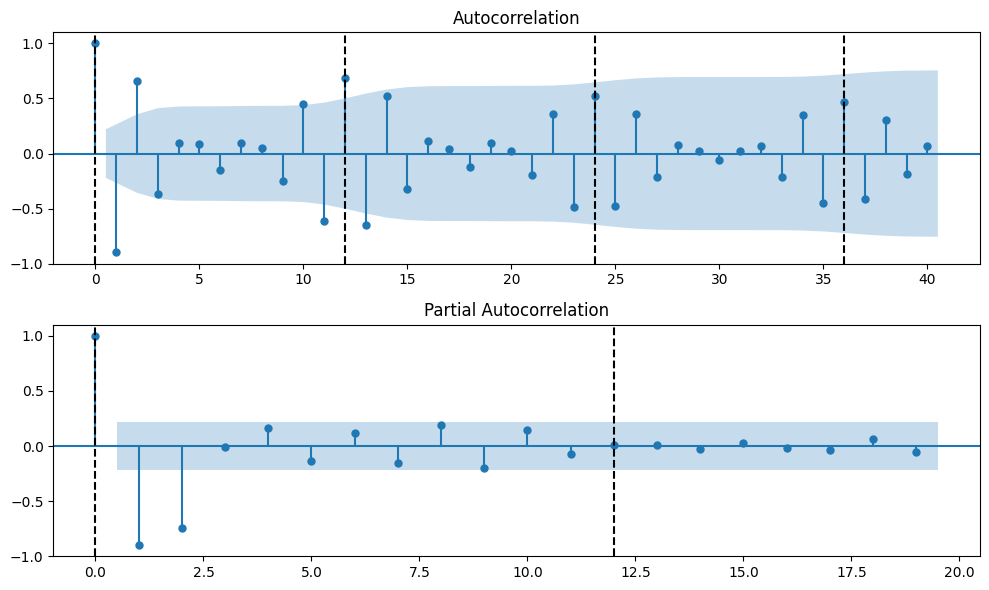

In [15]:
# Check ACF and PACF
LAGS = 40

fig, ax = plt.subplots(2,1, figsize=(10,6))

plot_acf(diff_12, lags=LAGS, ax=ax[0])
ax[0].vlines(list(range(0,LAGS,12)), ymin=-1, ymax=1.1, color='black', linestyle='--')
ax[0].set_ylim(-1,1.1)

plot_pacf(diff_12, lags=LAGS/2-1, ax=ax[1])
ax[1].vlines(list(range(0,int(LAGS/2-1),12)), ymin=-1, ymax=1.1, color='black', linestyle='--')
ax[1].set_ylim(-1,1.1)

plt.tight_layout()
plt.show()

In [17]:
# smoothen 2020 
mean_19_21 = (df.loc['2019-01':'2019-06', 'total_encounters'].to_numpy() + df.loc['2021-01':'2021-06', 'total_encounters'].to_numpy()) / 2
df['total_encounters_c'] = df['total_encounters'].astype(float)
df.loc['2020-01':'2020-06', 'total_encounters_c'] = mean_19_21

train = df[df.index.year < 2025]
test = df[df.index.year >= 2025]

In [22]:
model = pm.auto_arima(
    y=train['total_encounters'],
    seasonal=True,
    m=12,
    error_action='ignore',
    suppress_warnings=True,
)

In [14]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                   84
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 12)   Log Likelihood                -667.090
Date:                            Fri, 23 Jan 2026   AIC                           1344.181
Time:                                    19:42:41   BIC                           1356.275
Sample:                                01-01-2018   HQIC                          1349.040
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7109      0.081      8.741      0.000       0.552       0.870
ma.L1         -0.9408      0.053    -17.635      0.000      -1.045      -0.836
ar.S.L12       0.9488      0.134      7.064      0.000       0.686       1.212
ma.S.L12      -0.8140      0.261     -3.119      0.002      -1.326      -0.303
sigma2      4.464e+05   8.27e+04      5.396      0.000    2.84e+05    6.09e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                57.93
Prob(Q):                              0.90   Prob(JB):                         0.00
Heteroskedasticity (H):               0.23   Skew:                            -1.12
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.42
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

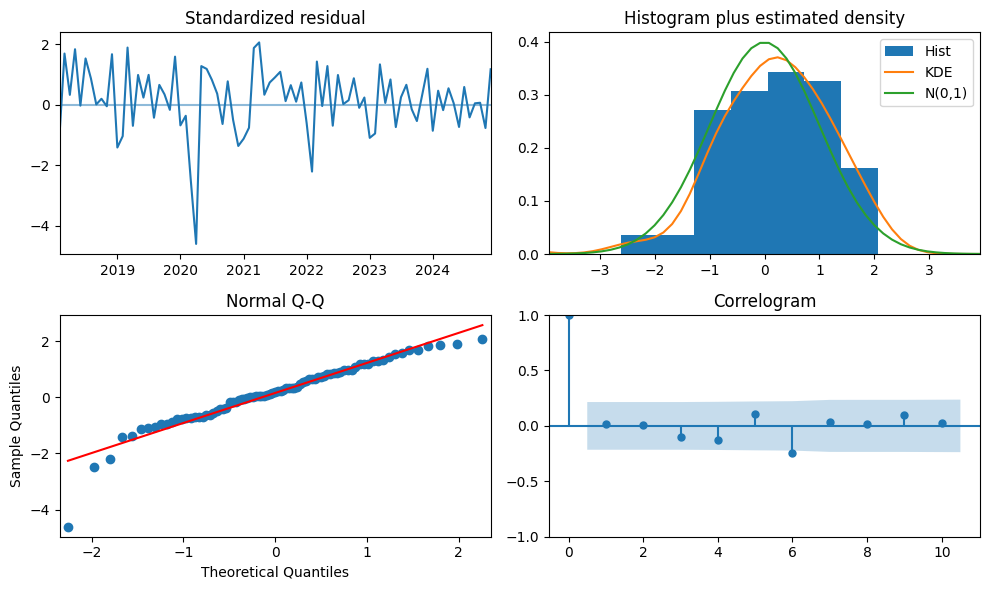

In [23]:
model.plot_diagnostics(figsize=(10,6))
plt.tight_layout()
plt.show()

In [34]:
preds = model.predict(n_periods=8)

All values are above 0.05. We fail to reject the null hypothesis. The residuals are uncorrelated


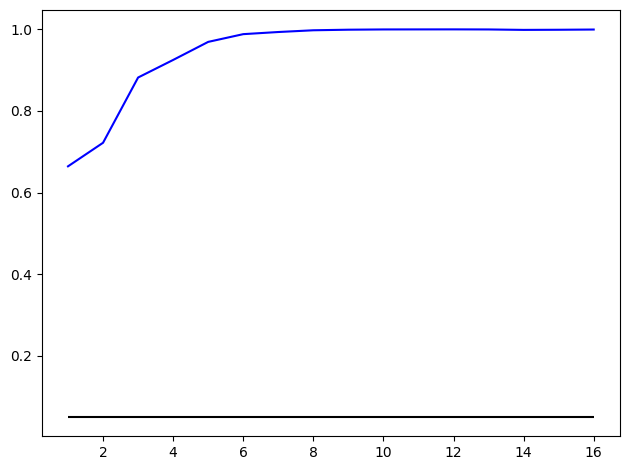

In [40]:
ljung_box_test(model.resid(), is_seasonal=True, period=12)

In [48]:
MAPE = mape(test['total_encounters'].to_numpy().flatten(), preds.to_numpy())
MAE = mae(test['total_encounters'].to_numpy().flatten(), preds.to_numpy())

In [41]:
df['is_2020_shock'] = 0
df.loc['2020-01-01':'2020-06-01', 'is_2020_shock'] = 1

train_exog = df.loc[train.index, 'is_2020_shock']
test_exog = df.loc[test.index, 'is_2020_shock']



model_with_exog = pm.auto_arima(
    y=train['total_encounters'],
    X=train_exog.to_numpy().reshape(-1,1),
    seasonal=True,
    m=12,
    error_action='ignore',
    suppress_warnings=True,
)


In [21]:
model_with_exog.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                   84
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 12)   Log Likelihood                -666.224
Date:                            Fri, 23 Jan 2026   AIC                           1344.448
Time:                                    19:42:58   BIC                           1358.961
Sample:                                01-01-2018   HQIC                          1350.278
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1          -492.8480    889.905     -0.554      0.580   -2237.030    1251.334
ar.L1          0.6811      0.089      7.634      0.000       0.506       0.856
ma.L1         -0.9372      0.054    -17.335      0.000      -1.043      -0.831
ar.S.L12       0.9384      0.136      6.902      0.000       0.672       1.205
ma.S.L12      -0.7940      0.250     -3.174      0.002      -1.284      -0.304
sigma2      4.389e+05   8.27e+04      5.306      0.000    2.77e+05    6.01e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                55.56
Prob(Q):                              0.88   Prob(JB):                         0.00
Heteroskedasticity (H):               0.24   Skew:                            -1.12
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.32
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

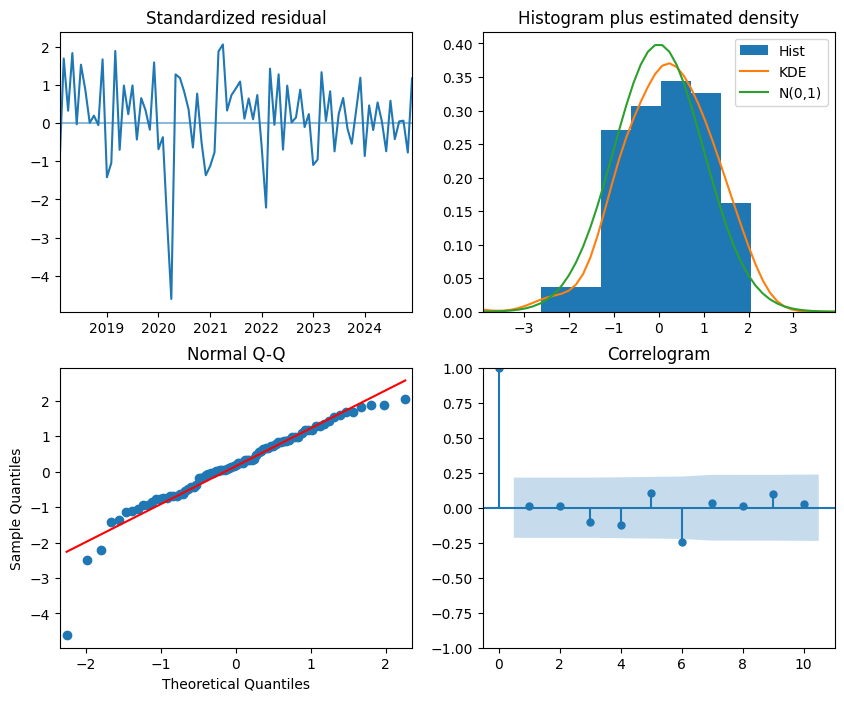

In [45]:
model.plot_diagnostics(figsize=(10,8))
plt.show()


In [46]:
preds_x = model_with_exog.predict(n_periods=8, X=np.zeros((8,1)))
preds_x.to_numpy()
MAPE_x = mape(test['total_encounters'].to_numpy().flatten(), preds_x.to_numpy())
MAE_x = mae(test['total_encounters'].to_numpy().flatten(), preds_x.to_numpy())


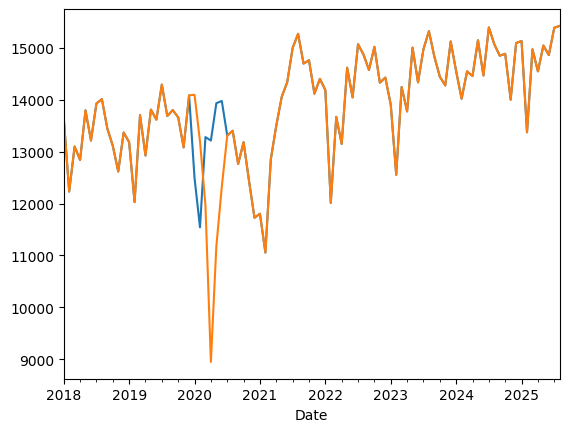

In [50]:
# smoothening the 2020 by interpolating the values from march 2020 to june 2020

df.total_encounters_c.plot(kind='line')
df.total_encounters.plot(kind='line')
plt.show()

In [51]:
model_with_corrected = pm.auto_arima(
    y=train['total_encounters_c'],
    seasonal=True,
    m=12,
    error_action='ignore',
    suppress_warnings=True,
)


In [52]:
preds_c = model_with_corrected.predict(n_periods=8)
MAPE_c = mape(test['total_encounters_c'].to_numpy().flatten(), preds_c.to_numpy())
MAE_c = mae(test['total_encounters_c'].to_numpy().flatten(), preds_c.to_numpy())

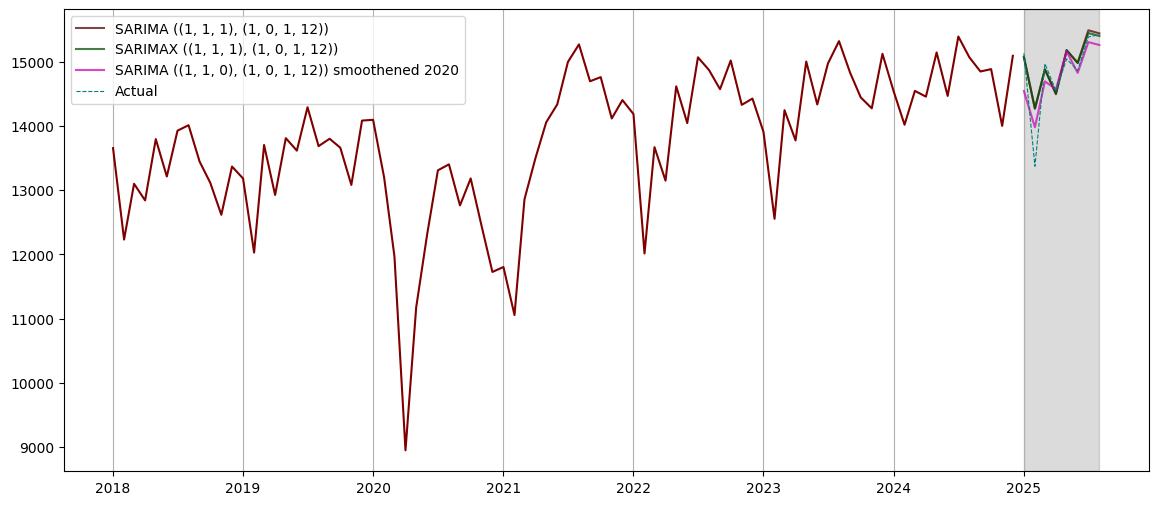

In [53]:
plt.figure(figsize=(14,6))
plt.plot(train['total_encounters'], color='maroon')
plt.plot(preds, color="#4D0000B8", label=f'SARIMA {model.get_params()['order'], model.get_params()['seasonal_order']}')
plt.plot(preds_x, color="#004D03B9",label=f'SARIMAX {model_with_exog.get_params()['order'], model_with_exog.get_params()['seasonal_order']}')
plt.plot(preds_c, color="#CB01B4B8", label=f'SARIMA {model_with_corrected.get_params()['order'], model_with_corrected.get_params()['seasonal_order']} smoothened 2020')

plt.plot(test['total_encounters'], linestyle='--', linewidth=0.8, color='teal', label='Actual')
plt.axvspan(test.index.min(), test.index.max(), color="#4D4D4D32", alpha=0.2)
plt.grid(axis='x')
plt.legend()
plt.show()

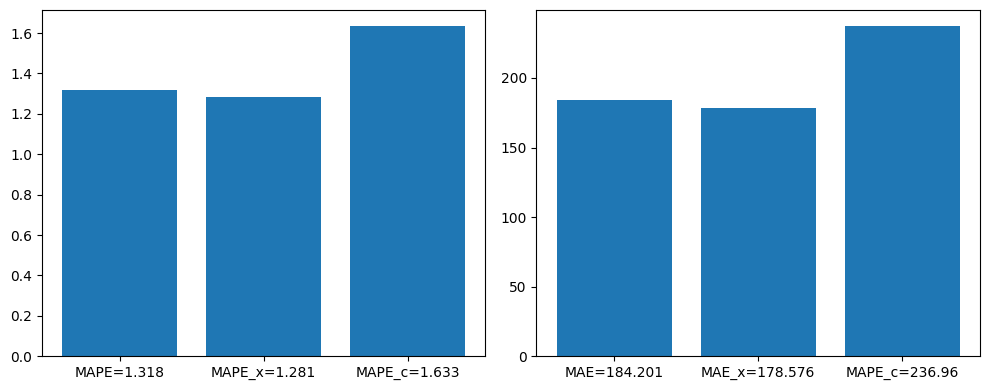

In [54]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))

ax[0].bar([f'MAPE={round(MAPE,3)}', f'MAPE_x={round(MAPE_x,3)}', f'MAPE_c={round(MAPE_c,3)}'], [MAPE, MAPE_x, MAPE_c])
ax[1].bar([f'MAE={round(MAE,3)}', f'MAE_x={round(MAE_x,3)}', f'MAPE_c={round(MAE_c,3)}'], [MAE, MAE_x, MAE_c])
plt.tight_layout()
plt.show()